In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from scipy import stats
from sklearn.ensemble import RandomForestRegressor

## Data Cleaning

In [2]:
data = pd.read_csv("retail_prices.csv")

In [3]:
data.head()


,Week,Item,Unit,Avg Price (Rs.),Price Range - low (Rs.),Price Range - High (Rs.)
0,2020-01-W1,Ash Plantain,1 kg.,180.83,140.00,240.0
1,2020-01-W1,Ash Pumpkin,1 kg.,160.00,120.00,200.0
2,2020-01-W1,Bandakka,1 kg.,273.10,200.00,320.0
3,2020-01-W1,Brinjal,1 kg.,281.21,240.00,400.0
4,2020-01-W1,Bitter Guard,1 kg.,313.55,200.00,400.0


In [4]:
print(data.isnull().sum())

Week                          0
Item                          0
Unit                          0
Avg Price (Rs.)               4
Price Range - low (Rs.)     927
Price Range - High (Rs.)    990
dtype: int64


In [5]:
data.shape

(22449, 6)

In [6]:
data = data.drop_duplicates()
data.dtypes

Week                        str
Item                        str
Unit                        str
Avg Price (Rs.)             str
Price Range - low (Rs.)     str
Price Range - High (Rs.)    str
dtype: object

In [7]:
# Convert str to float values

data['Avg Price (Rs.)'] = pd.to_numeric(data['Avg Price (Rs.)'],errors='coerce')
data['Price Range - low (Rs.)'] = pd.to_numeric(data['Price Range - low (Rs.)'],errors='coerce')
data['Price Range - High (Rs.)'] = pd.to_numeric(data['Price Range - High (Rs.)'],errors='coerce')

In [8]:
data.dtypes

Week                            str
Item                            str
Unit                            str
Avg Price (Rs.)             float64
Price Range - low (Rs.)     float64
Price Range - High (Rs.)    float64
dtype: object

In [9]:
# Drop rows where Avg Price is missing --> target variable
data = data.dropna(subset=['Avg Price (Rs.)'])

In [10]:
# Fill missing values in High and Low prices with Average price

data['Price Range - low (Rs.)'] = data['Price Range - low (Rs.)'].fillna(
    data['Avg Price (Rs.)']
)

data['Price Range - High (Rs.)'] = data['Price Range - High (Rs.)'].fillna(
    data['Avg Price (Rs.)']
)

In [11]:
# Encoding weeks from full dates to w1,w2,w3.....

#codes array start with 0.
codes, uniques = pd.factorize(data['Week'], sort=True)
data['Week_Encoded'] = [f'w{c+1}' for c in codes]

# creates a separate column with (1,2,3,.....)
data['Week_Num'] = codes + 1  

## Data Preprocessing

In [12]:
# Encoding catogarical columns

le_item = LabelEncoder()
data['Item_Encoded'] = le_item.fit_transform(data['Item'])

le_unit = LabelEncoder()
data['Unit_Encoded'] = le_unit.fit_transform(data['Unit'].astype(str))

In [13]:
# Feature transformation
data['Price_Difference'] = (
    data['Price Range - High (Rs.)'] - data['Price Range - low (Rs.)']
)

In [14]:
# Feature Selection

features = [
    'Week_Num',
    'Item_Encoded',
    'Unit_Encoded',
    'Price Range - low (Rs.)',
    'Price Range - High (Rs.)',
    'Price_Difference',
]
X = data[features]
y = data['Avg Price (Rs.)']

In [15]:
# Train-test data splitting (80% train, 20% test)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
# Feature scaling / normalization

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## EDA

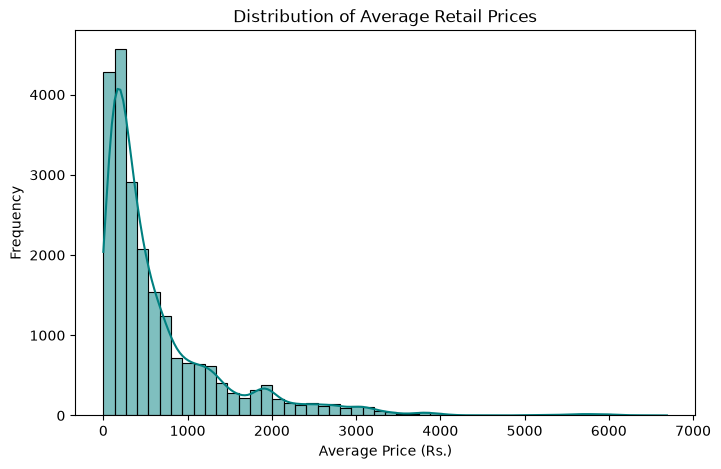

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(data['Avg Price (Rs.)'], bins=50, kde=True, color='teal')
plt.title('Distribution of Average Retail Prices')
plt.xlabel('Average Price (Rs.)')
plt.ylabel('Frequency')
plt.show()

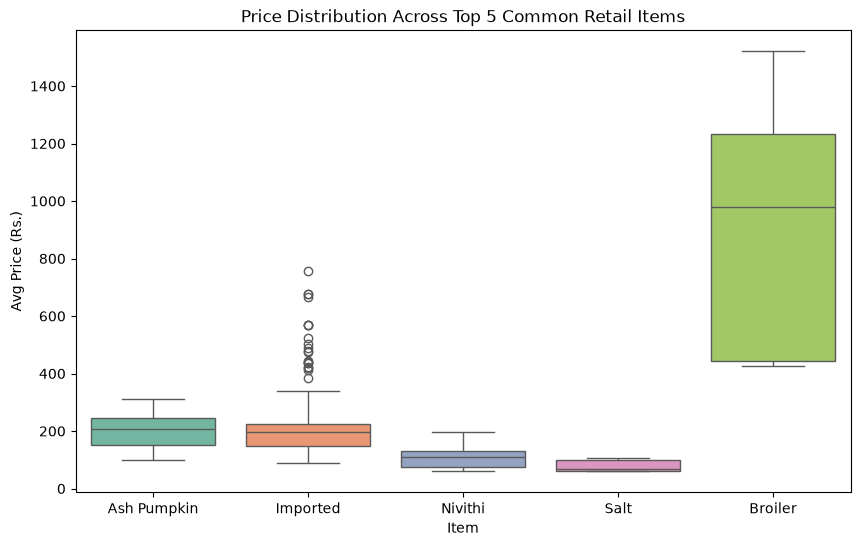

In [18]:
#Box plot

top_items = data['Item'].value_counts().head(5).index
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=data[data['Item'].isin(top_items)],
    x='Item',
    y='Avg Price (Rs.)',
    hue='Item',
    palette='Set2',
    legend=False,
)
plt.title('Price Distribution Across Top 5 Common Retail Items')
plt.show()

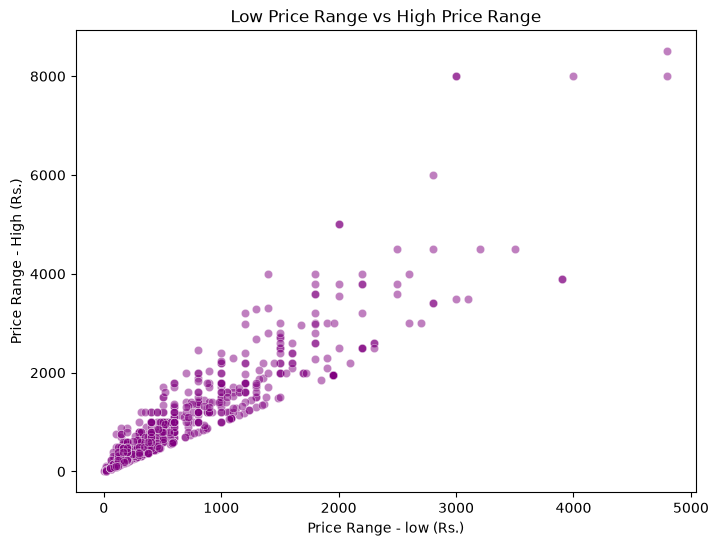

In [19]:
# Scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=data.sample(1000, random_state=42),
    x='Price Range - low (Rs.)',
    y='Price Range - High (Rs.)',
    alpha=0.5,
    color='purple',
)
plt.title('Low Price Range vs High Price Range')
plt.show()

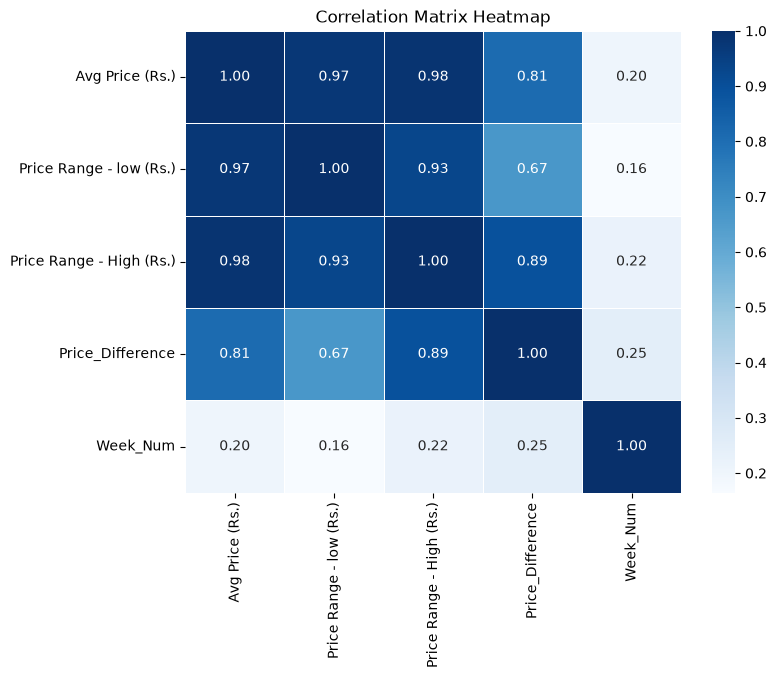

In [20]:
# Correlation heatmap

plt.figure(figsize=(8, 6))
#getting all the price values to an array
corr = data[
    [
        'Avg Price (Rs.)',
        'Price Range - low (Rs.)',
        'Price Range - High (Rs.)',
        'Price_Difference',
        'Week_Num',
    ]
].corr()
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

## Hypothesis testing

In [21]:
# Test 1
item_a_prices = data[data['Item'] == top_items[0]]['Avg Price (Rs.)']
item_b_prices = data[data['Item'] == top_items[1]]['Avg Price (Rs.)']
t_stat, p_val_1 = stats.ttest_ind(
    item_a_prices, item_b_prices, equal_var=False
)

print('--- Item Price Comparison ---\n')
print(f'H₀: There is no significant difference in mean price between items.') #Null hypothesis
print(f'H₁: There is a significant difference in mean price.') #Alternative hypothesis

print(f't-statistic: {t_stat:.4f}') # t-value
print(f'p-value: {p_val_1:.5e}') #p-value

#Conclution
if p_val_1 < 0.05:
  print('\nConclusion: Reject H₀ (Significant difference found).')
else:
  print('\nConclusion: Fail to reject H₀ (No significant difference found).')

--- Item Price Comparison ---

H₀: There is no significant difference in mean price between items.
H₁: There is a significant difference in mean price.
t-statistic: -24.8234
p-value: 6.67093e-66

Conclusion: Reject H₀ (Significant difference found).


In [22]:
# Test 2
corr_val, p_val_2 = stats.pearsonr(data['Week_Num'], data['Avg Price (Rs.)'])

print('\n--- Time Trend Correlation ---\n')
print(f'H₀: There is no correlation between time (Week) and Average Price.') #Null hypothesis
print(f'H₁: There is a significant correlation over time.') #Alternative hypothesis
print(f'Pearson r: {corr_val:.4f}')
print(f'p-value: {p_val_2:.5e}')

if p_val_2 < 0.05:
  print('\nConclusion: Reject H₀ (Significant correlation over time)')
else:
  print('\nConclusion: Fail to reject H₀ (No significant correlation)')


--- Time Trend Correlation ---

H₀: There is no correlation between time (Week) and Average Price.
H₁: There is a significant correlation over time.
Pearson r: 0.2010
p-value: 6.00845e-203

Conclusion: Reject H₀ (Significant correlation over time)


## Machine learning models

In [23]:
#Linear regression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_predictions = lr.predict(X_test_scaled)

print('\n--- Linear Regression ---\n')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, lr_predictions)):.2f}')
print(f'R² Score: {r2_score(y_test, lr_predictions):.4f}')


--- Linear Regression ---

RMSE: 61.20
R² Score: 0.9940


In [24]:
#Random Forest Regressor

rf = RandomForestRegressor(n_estimators=50, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_predictions = rf.predict(X_test_scaled)
print('\n--- Random Forest Regressor ---\n')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, rf_predictions)):.2f}')
print(f'R² Score: {r2_score(y_test, rf_predictions):.4f}')


--- Random Forest Regressor ---

RMSE: 49.65
R² Score: 0.9960
